# Case Closed — Node-Level Suspect Prediction (GNN project) — v5

## 1. Problem framing  *(Odabir problema — Section 1)*

**Prediction level: node-level.** Each case is one small heterogeneous graph
(persons / locations / objects / clues). We classify **person nodes tagged
`suspect`** — not every person node, and not the whole graph — as *murderer*
vs *not murderer*.

**Head / loss.** Because exactly one suspect is guilty per case, this is
framed as a **per-graph softmax over the candidate suspects** (pick the most
likely suspect out of that case's suspect set), trained with **per-graph
cross-entropy**.

**Why softmax, and not ReLU / ELU / some other activation function?**
These aren't competing choices — they answer different questions and
normally both show up in the same model:

- **ReLU / ELU / GELU** are *hidden-layer* activations. They sit between
  the linear layers inside the GNN (and inside an MLP baseline) and exist
  purely to make the network non-linear — without them, stacking layers
  would collapse into one big linear function no matter how many layers you
  add. They act **elementwise** and have no notion of "these numbers belong
  to the same group and should be compared to each other."
- **Softmax** is an *output-layer* normalization, used when the answer is
  "pick one out of a set of N options." It takes N raw scores (logits) —
  one per suspect in a case — and turns them into a probability
  distribution: every value in `[0, 1]`, and the whole set **sums to 1**.
  That's what makes it usable with **cross-entropy**, which is defined in
  terms of a probability assigned to the correct class.

  Concretely: a case with 4 suspects produces 4 logits from the model.
  ReLU on those 4 numbers just clips the negative ones to 0 — the result
  doesn't sum to 1 and doesn't shrink as more suspects are added, so it
  can't be read as "how likely is each person." Softmax normalizes across
  exactly those 4 numbers, so adding a 5th suspect correctly makes each
  individual probability smaller (there's more competition for the same
  1.0 of "guilt"). That's the property node-level "pick the murderer among
  these candidates" needs, and it's *not* something ReLU/ELU are trying to
  provide.

  So the actual model still uses ReLU/ELU internally (in the GNN's hidden
  layers and the MLP baseline) — softmax is only the last step, applied to
  the per-suspect output scores within each case.

**Domain.** Whodunit reasoning over structured case data extracted from
*Case Closed* (Detective Conan) episodes: who-knows-who, who-was-where,
who-did-what, tied to physical evidence and testimony.

**Dataset.** `cases_v3` schema (loader: `case_closed_dataset.py`). Each case
is its own self-contained graph, so cases — not individual nodes — are the
natural unit for train/val/test splitting (Section 4 of the plan).

**What's new in v5 vs v4:**
- More explanation, less "trust me": what "suspects per case" means, why
  softmax specifically, and what average degree / `2E/N` actually measure
  (see the markdown cells above each relevant table/chart below).
- Suspects-per-case and average-degree are now two separate, dedicated
  chart cells (each redrawn for readability: count labels, a marked mean)
  instead of one combined figure.
- The graph layout bug from v4 (components packed non-uniformly, so the
  main graph could render as a squished, overlapping sliver) is fixed in
  `visualize_case.py`: equal-aspect rendering plus a deterministic
  component ordering.
- The leak-scoring logic is a flat, single-threshold rule now: `action`
  keys at concentration ≥ 0.65 are EXCLUDE, everything else is kept — no
  intermediate "review" tier.
- A new **edge-removal step**: every edge whose type cleared that 0.65 bar
  is stripped from **every** case — not just the suspect-touching instances
  of it, the edge *type* is removed corpus-wide. The cleaned corpus is
  written out as a new dataset, `cases_v4`, in this notebook's own folder
  (`Reo analysis/v5/cases_v4/`) — a dataset-schema version bump, distinct
  from this notebook being "v5".
- The "top leak by concentration" chart (kept, as requested) now also
  reports how many edges were actually removed for each type.
- `ep011` (Moonlight Sonata) is re-visualized *after* cleaning, next to the
  original, so the effect of the removal is visible on a real case instead
  of only as aggregate counts.
- A new closing section starts the Section 7b bucket taxonomy: every edge
  key in the cleaned corpus, categorized (`action` vs `relationship`) and
  counted, as the catalog to actually assign buckets from next.

*Domain write-up wording for the report is still open — this notebook is the analysis that feeds it.*

---

## 2. Dataset understanding & audit  *(Dataset — Section 2)*

Below: load → schema map → per-case stats → corpus rundown →
suspects-per-case → role distribution → edge catalogue → example-case
visualization → leak audit → **edge removal & cleaned-dataset export**.
This feeds the Section 6 kritički osvrt / the exclusion list in the wider
plan.


In [1]:
# --- load data --------------------------------------------------------
import sys, os, math, json
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# this notebook lives in Reo analysis/v5/, two levels below the project root
# (Reo analysis/v5/ -> Reo analysis/ -> 2.0/), unlike v1-v4 which sat one
# level up -- case_closed_dataset.py / visualize_case.py live in 2.0/.
PROJECT_ROOT = os.path.abspath("../..")
sys.path.append(PROJECT_ROOT)
from case_closed_dataset import list_case_files, load_case, _edge_relation_key

DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "case_closed_dataset", "cases_v3")
files = list_case_files(DATA_ROOT)
all_cases = [load_case(f) for f in files]
print(f"{len(all_cases)} cases loaded from {DATA_ROOT}")


247 cases loaded from /home/reo/Faks/GNN/2.0/data/case_closed_dataset/cases_v3


In [2]:
# --- drop single-suspect cases -----------------------------------------
# A "case" = one episode = one graph. A "suspect" = a person node whose
# `roles` list contains "suspect" (as opposed to e.g. "witness" or
# "victim") -- these are the candidates the softmax head chooses between.
# A case with exactly 1 suspect has no real choice to make (accuracy is
# trivially 100%), so it adds noise to metrics without adding signal.
# Dropped here, once, so every cell below already works on the clean corpus.
def n_suspects(case):
    return sum(1 for p in case["nodes"]["persons"] if "suspect" in p.get("roles", []))

single_suspect_cases = [c["case_id"] for c in all_cases if n_suspects(c) == 1]
cases = [c for c in all_cases if n_suspects(c) > 1]

print(f"dropped {len(single_suspect_cases)} single-suspect cases, {len(cases)} remain")
print(single_suspect_cases)


dropped 10 single-suspect cases, 237 remain
['ep083_general_hospital_murder_case', 'ep148_the_streetcars_sudden_stopping_case', 'ep243-244_kogoro_mouris_imposter', 'ep658_the_hot_chocolate_trap', 'ep750_the_man_who_was_betrayed_by_the_sea', 'ep774_munchs_missing_scream', 'ep830-832_a_cottage_surrounded_by_zombies', 'ep840_the_last_gift', 'ep872-874_conan_and_heijis_nue_legend', 'ep907_the_j_league_bodyguard']


### Schema map

What a case JSON actually looks like, checked programmatically (not just
asserted) against every file in the corpus.


In [3]:
# --- schema map ----------------------------------------------------------
schema_versions = Counter(c.get("schema_version") for c in cases)
node_collections = Counter()
for c in cases:
    node_collections.update(c["nodes"].keys())

print("schema_version across corpus:", dict(schema_versions))
print("node collections present in every case:", dict(node_collections))
print("""
Nodes  = persons | locations | objects | clues   (heterogeneous, 4 types)
         persons:   id, name, aliases, roles[], occupation, attrs{}
         locations: id, name, attrs{}
         objects:   id, name, role, attrs{}
         clues:     id, desc, clue_type
Edges  = {type, from, to, order?, ...}            (directed, multigraph)
         'relationship' edges carry an extra relation_type (e.g. 'classmate')
Label  = {murderer_id: <one person id>}           (exactly one per case)
""")


schema_version across corpus: {'v3': 237}
node collections present in every case: {'persons': 237, 'locations': 237, 'objects': 237, 'clues': 237}

Nodes  = persons | locations | objects | clues   (heterogeneous, 4 types)
         persons:   id, name, aliases, roles[], occupation, attrs{}
         locations: id, name, attrs{}
         objects:   id, name, role, attrs{}
         clues:     id, desc, clue_type
Edges  = {type, from, to, order?, ...}            (directed, multigraph)
         'relationship' edges carry an extra relation_type (e.g. 'classmate')
Label  = {murderer_id: <one person id>}           (exactly one per case)



### Per-case stats

One row per case: node/edge counts and **average degree** (broj čvorova,
broj bridova, prosječni stupanj).

**What is "degree"?** The degree of a single node is just the number of
edges touching it. **Average degree** summarizes that across an entire
graph in one number: how many connections does a typical node have?

**Why `2E / N`?** Sum the degree of every node in a graph, and each edge
gets counted **twice** — once for each of its two endpoints (edge A↔B adds
1 to A's degree and 1 to B's degree). So `sum of all degrees = 2 × (number
of edges)`. Average degree is that sum divided by the number of nodes:

```
avg_degree = (sum of all node degrees) / N = 2·E / N
```

Example: a case with 20 nodes and 48 edges (roughly the corpus average) has
`2 × 48 / 20 = 4.8` — each node touches about 4.8 edges on average.


In [4]:
# --- per-case stats table -------------------------------------------------
rows = []
for c in cases:
    persons = c["nodes"]["persons"]
    n_locs, n_objs, n_clues = (len(c["nodes"][k]) for k in ("locations", "objects", "clues"))
    n_nodes = len(persons) + n_locs + n_objs + n_clues
    n_edges = len(c["edges"])
    rows.append(dict(
        case_id=c["case_id"], n_persons=len(persons), n_suspects=n_suspects(c),
        n_locations=n_locs, n_objects=n_objs, n_clues=n_clues,
        n_nodes=n_nodes, n_edges=n_edges, avg_degree=2 * n_edges / n_nodes,
    ))
stats = pd.DataFrame(rows)
stats.describe().loc[["mean", "min", "max"]]


,n_persons,n_suspects,n_locations,n_objects,n_clues,n_nodes,n_edges,avg_degree
mean,6.468354,3.421941,4.472574,6.64557,2.85654,20.443038,48.223629,4.720397
min,3.000000,2.000000,1.000000,1.00000,0.00000,10.000000,23.000000,2.960000
max,17.000000,8.000000,12.000000,13.00000,7.00000,37.000000,130.000000,7.379310


### Dataset rundown

Corpus-level headline numbers: how many node *types*, how many nodes of each
type in total, overall node/edge counts, and average degree.


In [5]:
# --- rundown: node types & corpus totals ----------------------------------
NODE_TYPES = ["persons", "locations", "objects", "clues"]
node_type_totals = {t: int(stats[f"n_{t}"].sum()) for t in NODE_TYPES}

print(f"cases: {len(cases)}")
print(f"node types: {len(NODE_TYPES)}  {NODE_TYPES}")
for t, n in node_type_totals.items():
    print(f"  {t:12s} {n:5d} total   ({n / len(cases):.2f} / case)")
print(f"nodes total: {sum(node_type_totals.values())}   edges total: {int(stats['n_edges'].sum())}")
print(f"avg degree (corpus-wide 2E/N): {2 * stats['n_edges'].sum() / stats['n_nodes'].sum():.3f}")


cases: 237
node types: 4  ['persons', 'locations', 'objects', 'clues']
  persons       1533 total   (6.47 / case)
  locations     1060 total   (4.47 / case)
  objects       1575 total   (6.65 / case)
  clues          677 total   (2.86 / case)
nodes total: 4845   edges total: 11429
avg degree (corpus-wide 2E/N): 4.718


### Suspects per case (softmax candidate-pool size & class balance)

**What is this, concretely?** Each *case* is one episode's graph. Within
that graph, some person nodes are tagged `suspect` in their `roles` list —
these are the people the story presents as plausible culprits (as opposed
to `witness`, `victim`, etc., who are part of the graph but never the
answer). "Suspects per case" = how many of those candidate nodes exist in
that one graph. This number **is** the size of the softmax over which the
model has to pick — a case with 3 suspects is a 3-way decision, a case with
6 suspects is a 6-way decision.

**What does the distribution/histogram show?** Not one number but how that
candidate-pool size varies across the whole corpus: e.g. "114 of our 237
cases have exactly 3 suspects, 30 cases have 2, only 1 case has 8." This
matters for two reasons: (1) it sets the difficulty floor — a 2-suspect
case has a 50% random-guess baseline, an 8-suspect case has ~12.5% — so raw
accuracy isn't comparable case-to-case without knowing this, and (2) it's
exactly the variable Section 4 of the plan stratifies the train/val/test
split by, so train and test see a similar mix of "easy" (few-suspect) and
"hard" (many-suspect) cases.


In [6]:
# --- suspects per case: distribution & class ratio (distribucija labela, omjer klasa) ---
n_cases = len(cases)
total_suspects = int(stats["n_suspects"].sum())

print(f"suspects/case: mean={stats['n_suspects'].mean():.2f}  "
      f"min={stats['n_suspects'].min()}  max={stats['n_suspects'].max()}")
print(f"suspects/case distribution: {sorted(stats['n_suspects'].value_counts().to_dict().items())}")
print(f"\nsuspect nodes total (softmax candidate pool, all cases): {total_suspects}")
print(f"  positives (the murderer): {n_cases}")
print(f"  negatives (other suspects): {total_suspects - n_cases}")
print(f"per-graph softmax baseline (avg of 1/n_suspects): {np.mean(1 / stats['n_suspects']):.3f}")
print(f"pooled-binary positive rate (murderer / all suspect nodes): {n_cases / total_suspects:.3f}")


suspects/case: mean=3.42  min=2  max=8
suspects/case distribution: [(2, 30), (3, 114), (4, 65), (5, 23), (6, 2), (7, 2), (8, 1)]

suspect nodes total (softmax candidate pool, all cases): 811
  positives (the murderer): 237
  negatives (other suspects): 574
per-graph softmax baseline (avg of 1/n_suspects): 0.315
pooled-binary positive rate (murderer / all suspect nodes): 0.292


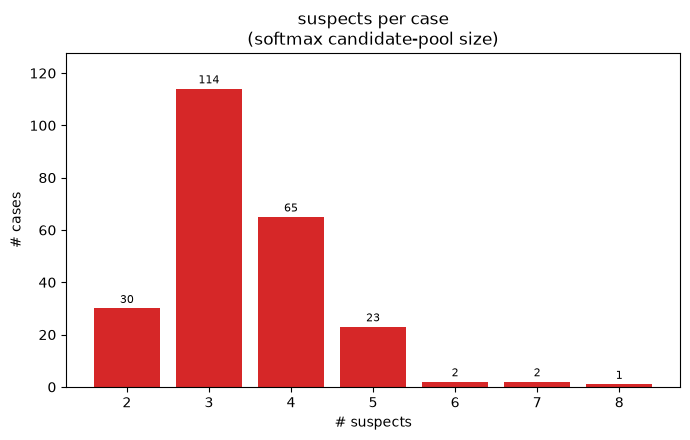

In [7]:
# --- viz: suspects per case (softmax candidate-pool size) ------------------
sc = stats["n_suspects"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(sc.index, sc.values, color="tab:red")
ax.bar_label(bars, padding=2, fontsize=8)
ax.set_title("suspects per case\n(softmax candidate-pool size)")
ax.set_xlabel("# suspects"); ax.set_ylabel("# cases")
ax.set_xticks(sc.index)
ax.margins(y=0.12)
plt.tight_layout()
plt.show()


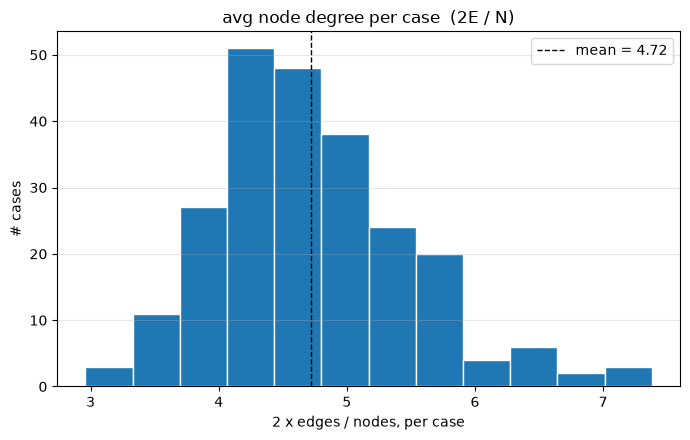

In [8]:
# --- viz: avg node degree per case (2E / N) ---------------------------------
mean_deg = stats["avg_degree"].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(stats["avg_degree"], bins=12, color="tab:blue", edgecolor="white")
ax.axvline(mean_deg, color="black", linestyle="--", linewidth=1, label=f"mean = {mean_deg:.2f}")
ax.set_title("avg node degree per case  (2E / N)")
ax.set_xlabel("2 x edges / nodes, per case"); ax.set_ylabel("# cases")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Person role distribution

A person node can hold more than one role (e.g. a `victim` who is also a
`backstory_figure`), so these counts don't sum to the number of person
nodes.


In [9]:
# --- person role distribution ---------------------------------------------
role_counter = Counter()
for c in cases:
    for p in c["nodes"]["persons"]:
        role_counter.update(p.get("roles", []))

for r, n in role_counter.most_common():
    print(f"  {r:18s} {n:4d}")


  suspect             811
  witness             404
  victim              384
  backstory_figure    264
  bystander            85
  client                1
  investigator          1


### Edge catalogue

Two different numbers show up later and it's worth being precise about why
they differ:

- **raw `type` values** — the literal `edges[i]["type"]` string (`kills`,
  `owns`, `was_at`, `relationship`, ...). Counted directly below.
- **collapsed keys** — the loader's `_edge_relation_key` folds every
  `relationship` edge into `rel:<relation_type>` (e.g. `rel:classmate`)
  instead of the generic `relationship`, so the relation vocabulary stays
  informative. That means the collapsed key space is `(raw types − 1 for
  "relationship") + (distinct relation_type values)` — strictly *more*
  keys than raw types, not fewer, because one generic bucket gets replaced
  by ~270 specific ones. The leak audit further restricts this to keys
  that touch at least one **suspect** node, which drops it back down.


In [10]:
# --- edge catalogue: raw types vs relation_type sub-types ------------------
edge_type_counter = Counter()
relation_type_counter = Counter()
for c in cases:
    for e in c["edges"]:
        edge_type_counter[e["type"]] += 1
        if e.get("relation_type"):
            relation_type_counter[e["relation_type"]] += 1

n_singleton_types = sum(1 for v in edge_type_counter.values() if v == 1)
collapsed_universe = len(edge_type_counter) - 1 + len(relation_type_counter)

print(f"unique raw edge 'type' verbs: {len(edge_type_counter)}  "
      f"({n_singleton_types} appear in only 1 edge -- long tail)")
print(f"unique relation_type values (sub-typing 'relationship' edges): {len(relation_type_counter)}")
print(f"collapsed key space ({len(edge_type_counter)} - 1 + {len(relation_type_counter)}): {collapsed_universe}")
print("\ntop 12 raw edge types by frequency:")
for t, n in edge_type_counter.most_common(12):
    print(f"  {t:22s} {n:5d}")


unique raw edge 'type' verbs: 625  (389 appear in only 1 edge -- long tail)
unique relation_type values (sub-typing 'relationship' edges): 271
collapsed key space (625 - 1 + 271): 895

top 12 raw edge types by frequency:
  was_at                  2990
  relationship            1339
  implicates              1323
  regarding               1294
  owns                     676
  has_motive_against       599
  located_in               464
  kills                    288
  leaves_evidence          271
  stages_alibi_using       210
  confronts                116
  steals                    73


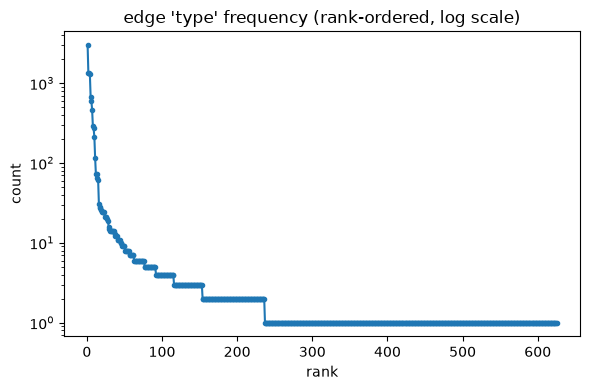

In [11]:
# --- viz: edge 'type' frequency long tail (log scale) ----------------------
freqs = sorted(edge_type_counter.values(), reverse=True)
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(freqs) + 1), freqs, marker=".")
plt.yscale("log")
plt.title("edge 'type' frequency (rank-ordered, log scale)")
plt.xlabel("rank"); plt.ylabel("count")
plt.tight_layout()
plt.show()


### Example case: reading one graph before trusting the aggregate stats

`ep011` ("Moonlight Sonata Murder Case") is the running example case —
persons colored red if tagged `suspect`, blue otherwise, with the
murderer's name marked. Layout: node positions are computed on a
de-duplicated simple graph so pairs joined by many parallel edges don't
collapse into an unreadable clump; every original (possibly parallel) edge
is still drawn. This is the **original** version — it's redrawn again after
the leak-removal step below so the two can be compared.


case: Moonlight Sonata Murder Case
persons=12 suspects=8 locations=5 objects=8 clues=2 edges=98
murderer: Narumi Asai  (p8)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


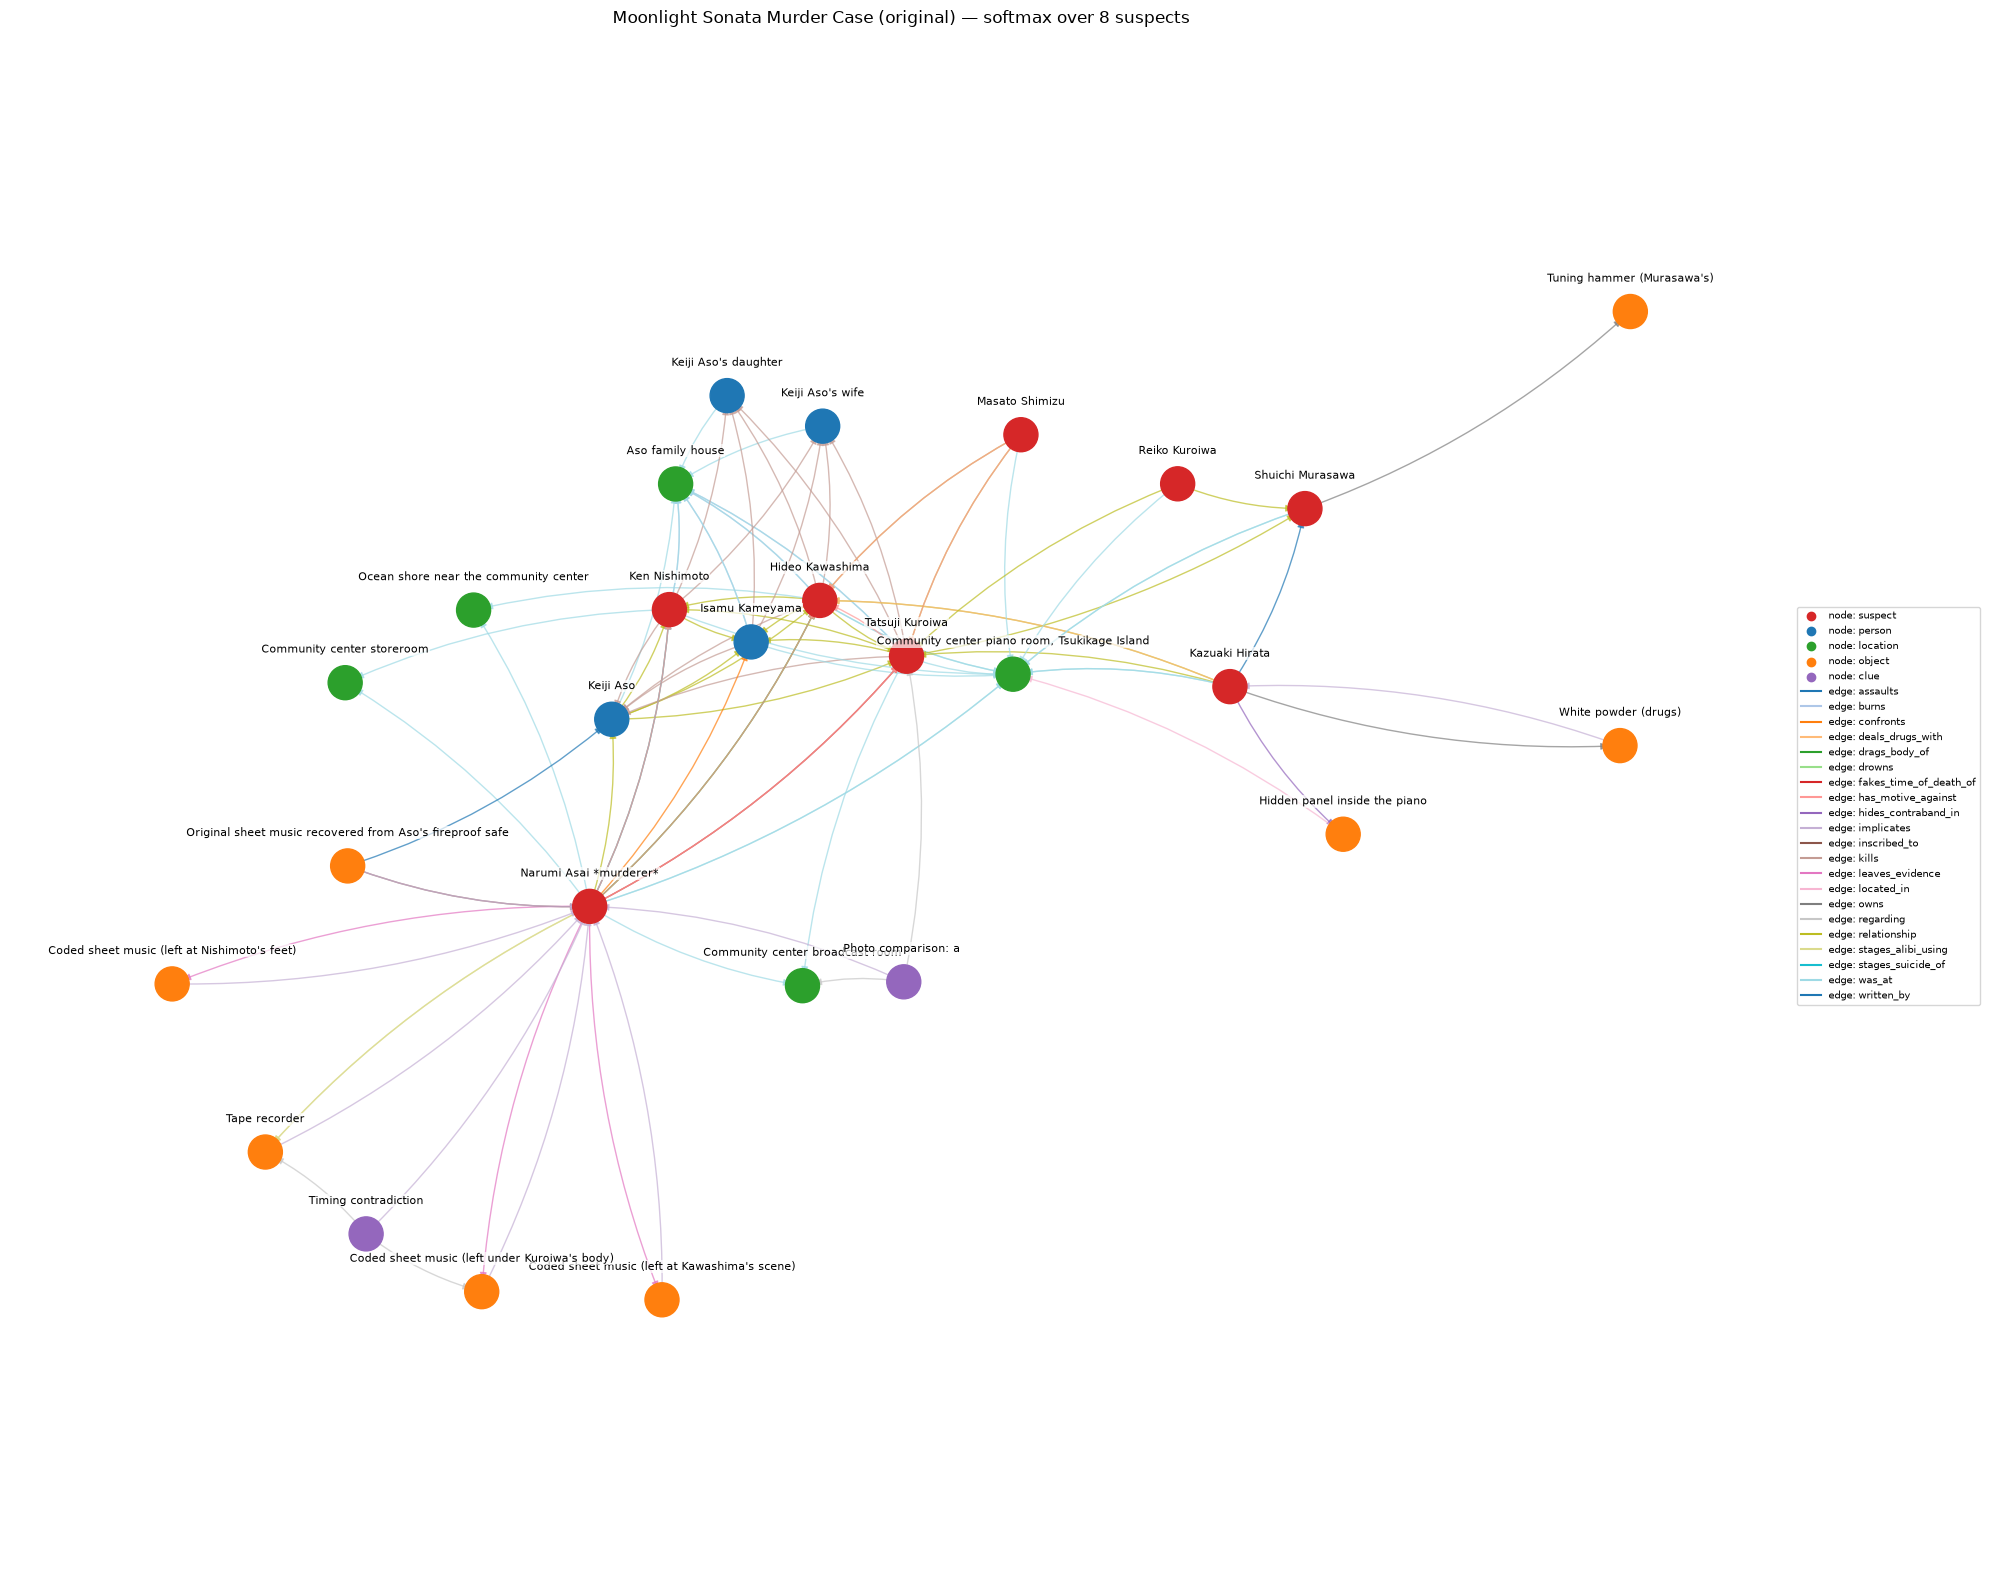

In [12]:
# --- visualize moonlight sonata (original) ----------------------------------
from visualize_case import load_case as load_case_for_viz, draw_case

example_path = os.path.join(DATA_ROOT, "ep011_moonlight_sonata_murder_case.json")
example = load_case_for_viz(example_path)

ex_persons = example["nodes"]["persons"]
ex_suspects = [p for p in ex_persons if "suspect" in p.get("roles", [])]
ex_murderer_id = example["label"]["murderer_id"]
ex_murderer = next(p for p in ex_persons if p["id"] == ex_murderer_id)

print(f"case: {example['title']}")
print(f"persons={len(ex_persons)} suspects={len(ex_suspects)} "
      f"locations={len(example['nodes']['locations'])} "
      f"objects={len(example['nodes']['objects'])} "
      f"clues={len(example['nodes']['clues'])} edges={len(example['edges'])}")
print(f"murderer: {ex_murderer['name']}  ({ex_murderer_id})")

draw_case(example, title=f"{example['title']} (original) — softmax over {len(ex_suspects)} suspects")


### Leak audit: which edge types "give away" the murderer?

Some edges only exist in the graph *because* the story's solution already
happened — e.g. a `kills` or `stages_alibi_using` edge is authored by
someone who already knows who did it. A GNN trained on those edges wouldn't
be learning detective reasoning, it would be reading the answer key.

**Metric.** For every edge key (top-level `type`, or `relation_type` for
`relationship` edges), and for every case, find which **suspect** nodes
that key touches (as `from` or `to`) — restricted to suspects because
that's the softmax candidate pool the model actually chooses between. Note
that "touches a suspect" says nothing about what's on the *other* end of
the edge — the other endpoint can just as easily be an object, a location,
or a clue as another person (`owns` connects a suspect to an *object*,
`hides_contraband_in` to a *location*, `implicates` to an *object or
clue*). Then define a single **concentration score**:

```
concentration(key) = murderer_touches(key) / (murderer_touches(key) + other_suspect_touches(key))
```

i.e. *of every suspect this edge key ever touches, what fraction are the
murderer.* Bounded in **[0, 1]**:

- **≈ base rate (murderers / all suspects, ≈0.29 in this corpus)** → no
  signal — the edge type is no more likely to touch the murderer than to
  touch anyone else.
- **→ 1.0** → almost every suspect this edge type ever touches turns out to
  be the murderer — a giveaway.

**Minimum support.** Only edge keys that touch the **murderer in at least
10 different cases** are scored — a key seen touching the murderer once or
twice and never anyone else would otherwise score a meaningless 1.0.

**Sanity check to watch for below:** `was_at` (pure location co-presence,
about as uninformative as an edge type gets here) should land close to the
~0.29 base rate — an uninformative edge type should score near baseline,
not near 0 or 1.

**Threshold: 0.65.** `relationship` sub-types (`rel:classmate`,
`rel:spouse_of`, ...) are never auto-excluded no matter their score — they
encode *pre-existing* social facts (motive signal a real detective is
allowed to use). Among `action` keys (`kills`, `owns`, ...), concentration
≥ 0.65 means removal: mostly *what happened during the crime*, i.e.
post-hoc narration only the killer/narrator would know.


In [13]:
# --- leaks: compute per-key touch counts -----------------------------------
murderer_touch = Counter()          # key -> # cases where the murderer is touched
other_touch = Counter()             # key -> # (case, non-murderer-suspect) pairs touched
case_support = defaultdict(set)     # key -> set of case_ids where key touches ANY suspect

for c in cases:
    persons = c["nodes"]["persons"]
    suspect_ids = {p["id"] for p in persons if "suspect" in p.get("roles", [])}
    murderer_id = c["label"]["murderer_id"]
    other_ids = suspect_ids - {murderer_id}

    touched_by = defaultdict(set)   # key -> suspect ids touched, this case
    for e in c["edges"]:
        key = _edge_relation_key(e)   # 'kills', 'owns', ... or 'rel:classmate', ...
        for endpoint in (e["from"], e["to"]):
            if endpoint in suspect_ids:
                touched_by[key].add(endpoint)

    for key, ids in touched_by.items():
        case_support[key].add(c["case_id"])
        if murderer_id in ids:
            murderer_touch[key] += 1
        other_touch[key] += len(ids & other_ids)

print(f"{len(case_support)} distinct edge keys touch at least one suspect")


747 distinct edge keys touch at least one suspect


In [14]:
# --- leaks: concentration score + thresholding ------------------------------
MIN_MURDERER_SUPPORT = 10   # only score keys that touch the murderer in >=10 cases.
                             # (Verbs with fewer touches than this -- e.g. `strangles`,
                             # `orders` -- are reviewed manually below instead of being
                             # auto-flagged: at n<10 the concentration score is too noisy to
                             # threshold on its own -- see the manual-review section.)
EXCLUDE_THRESHOLD = 0.65    # action-verb edges >= this: confident post-hoc-narration leak

base_rate = n_cases / total_suspects  # reference line: "no signal" concentration

leak_rows = []
for key, cids in case_support.items():
    m, o = murderer_touch[key], other_touch[key]
    if m < MIN_MURDERER_SUPPORT:
        continue
    concentration = m / (m + o)
    leak_rows.append(dict(
        edge_key=key, category="relationship" if key.startswith("rel:") else "action",
        support_cases=len(cids), murderer_touches=m, other_suspect_touches=o,
        murderer_rate=m / n_cases, other_suspect_rate=o / (total_suspects - n_cases),
        concentration=concentration,
    ))

leak_df = pd.DataFrame(leak_rows).sort_values("concentration", ascending=False).reset_index(drop=True)
print(f"base rate (murderers / all suspects): {base_rate:.3f}")
print(f"{len(leak_df)} edge keys with murderer support >= {MIN_MURDERER_SUPPORT}")
leak_df


base rate (murderers / all suspects): 0.292
35 edge keys with murderer support >= 10


,edge_key,category,support_cases,murderer_touches,other_suspect_touches,murderer_rate,other_suspect_rate,concentration
0,poisons,action,20,19,1,0.080169,0.001742,0.950000
1,stages_alibi_using,action,118,115,7,0.485232,0.012195,0.942623
2,drags_body_of,action,23,23,2,0.097046,0.003484,0.920000
3,wears,action,11,10,1,0.042194,0.001742,0.909091
4,uses,action,41,39,4,0.164557,0.006969,0.906977
5,hides_contraband_in,action,18,16,2,0.067511,0.003484,0.888889
6,kills,action,192,191,25,0.805907,0.043554,0.884259
7,drugs,action,14,14,2,0.059072,0.003484,0.875000
8,leaves_evidence,action,128,125,19,0.527426,0.033101,0.868056
9,stages_suicide_of,action,26,25,4,0.105485,0.006969,0.862069


In [15]:
# --- leaks: which keys cross the 0.65 threshold -----------------------------
over_threshold = (leak_df["category"] == "action") & (leak_df["concentration"] >= EXCLUDE_THRESHOLD)
exclude_list = leak_df[over_threshold]

print(f"{len(exclude_list)} of {len(leak_df)} edge keys are >= {EXCLUDE_THRESHOLD} concentration")
leak_df


19 of 35 edge keys are >= 0.65 concentration


,edge_key,category,support_cases,murderer_touches,other_suspect_touches,murderer_rate,other_suspect_rate,concentration
0,poisons,action,20,19,1,0.080169,0.001742,0.950000
1,stages_alibi_using,action,118,115,7,0.485232,0.012195,0.942623
2,drags_body_of,action,23,23,2,0.097046,0.003484,0.920000
3,wears,action,11,10,1,0.042194,0.001742,0.909091
4,uses,action,41,39,4,0.164557,0.006969,0.906977
5,hides_contraband_in,action,18,16,2,0.067511,0.003484,0.888889
6,kills,action,192,191,25,0.805907,0.043554,0.884259
7,drugs,action,14,14,2,0.059072,0.003484,0.875000
8,leaves_evidence,action,128,125,19,0.527426,0.033101,0.868056
9,stages_suicide_of,action,26,25,4,0.105485,0.006969,0.862069


### Remove the leaked edge types and export a cleaned dataset

This is the concrete data-quality fix, not just an audit: every edge whose
**type** cleared the EXCLUDE bar (concentration ≥ 0.65) is dropped from
**every** case in the corpus — the edge *type* is removed wholesale, not
just its suspect-touching instances. (In practice this is exactly
`exclude_list` above — no `relationship` sub-type reaches 0.65 in this
corpus, so category-restricting it or not makes no difference here, but the
category rule stays in the code as the actual safeguard.) Nodes are left
untouched; only edges are dropped, so node counts before/after are
unchanged even where edge counts drop a lot.

The cleaned cases are written out as a new dataset version, **`cases_v4`**
(schema-version bump; unrelated to this notebook being "v5"), saved next to
this notebook at `Reo analysis/v5/cases_v4/`.


In [16]:
# --- remove all edges of every EXCLUDE-tier type, corpus-wide --------------
EXCLUDED_KEYS = set(exclude_list["edge_key"])

removed_edge_counts = Counter()   # key -> # edges removed, corpus-wide
cleaned_cases = []
for c in cases:
    kept_edges = []
    for e in c["edges"]:
        key = _edge_relation_key(e)
        if key in EXCLUDED_KEYS:
            removed_edge_counts[key] += 1
        else:
            kept_edges.append(e)
    cleaned = dict(c)          # shallow copy: only "edges" changes below
    cleaned["edges"] = kept_edges
    cleaned["schema_version"] = "v4"
    cleaned_cases.append(cleaned)

total_removed = sum(removed_edge_counts.values())
total_kept = sum(len(c["edges"]) for c in cleaned_cases)
total_original = total_removed + total_kept

print(f"removing {len(EXCLUDED_KEYS)} edge types: {sorted(EXCLUDED_KEYS)}")
print(f"\nremoved {total_removed} edges corpus-wide, {total_kept} remain "
      f"({total_removed / total_original:.1%} of all {total_original} edges)")


removing 19 edge types: ['burns', 'drags_body_of', 'drugs', 'fakes_time_of_death_of', 'hides_contraband_in', 'impersonates', 'implicates', 'kills', 'leaves_evidence', 'lures', 'poisons', 'sabotages', 'stages_alibi_using', 'stages_suicide_of', 'steals', 'tampers_with', 'uses', 'wears', 'written_by']

removed 2548 edges corpus-wide, 8881 remain (22.3% of all 11429 edges)


In [17]:
# --- write the cleaned cases_v4 dataset -------------------------------------
OUT_DIR = os.path.join(os.getcwd(), "cases_v4")
os.makedirs(OUT_DIR, exist_ok=True)

for cleaned in cleaned_cases:
    out_path = os.path.join(OUT_DIR, f"{cleaned['case_id']}.json")
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(cleaned, f, indent=2, ensure_ascii=False)

print(f"wrote {len(cleaned_cases)} cleaned case files to {OUT_DIR}")
print(f"(single-suspect cases dropped earlier are not included: {len(single_suspect_cases)} fewer files than the raw cases_v3 corpus)")


wrote 237 cleaned case files to /home/reo/Faks/GNN/2.0/Reo analysis/v5/cases_v4
(single-suspect cases dropped earlier are not included: 10 fewer files than the raw cases_v3 corpus)


### Moonlight Sonata, again — after cleaning

Same case, same layout function, but drawn straight from `cleaned_cases`
(not re-loaded from disk) so this is exactly what the exported `cases_v4`
file for `ep011` looks like. Compare against the "original" render above:
same nodes, fewer edges — every `kills`, `stages_alibi_using`,
`leaves_evidence`, `implicates`, ... edge is gone, along with the other 15
EXCLUDE-tier types.


case: Moonlight Sonata Murder Case
edges before cleaning: 98   after: 62


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


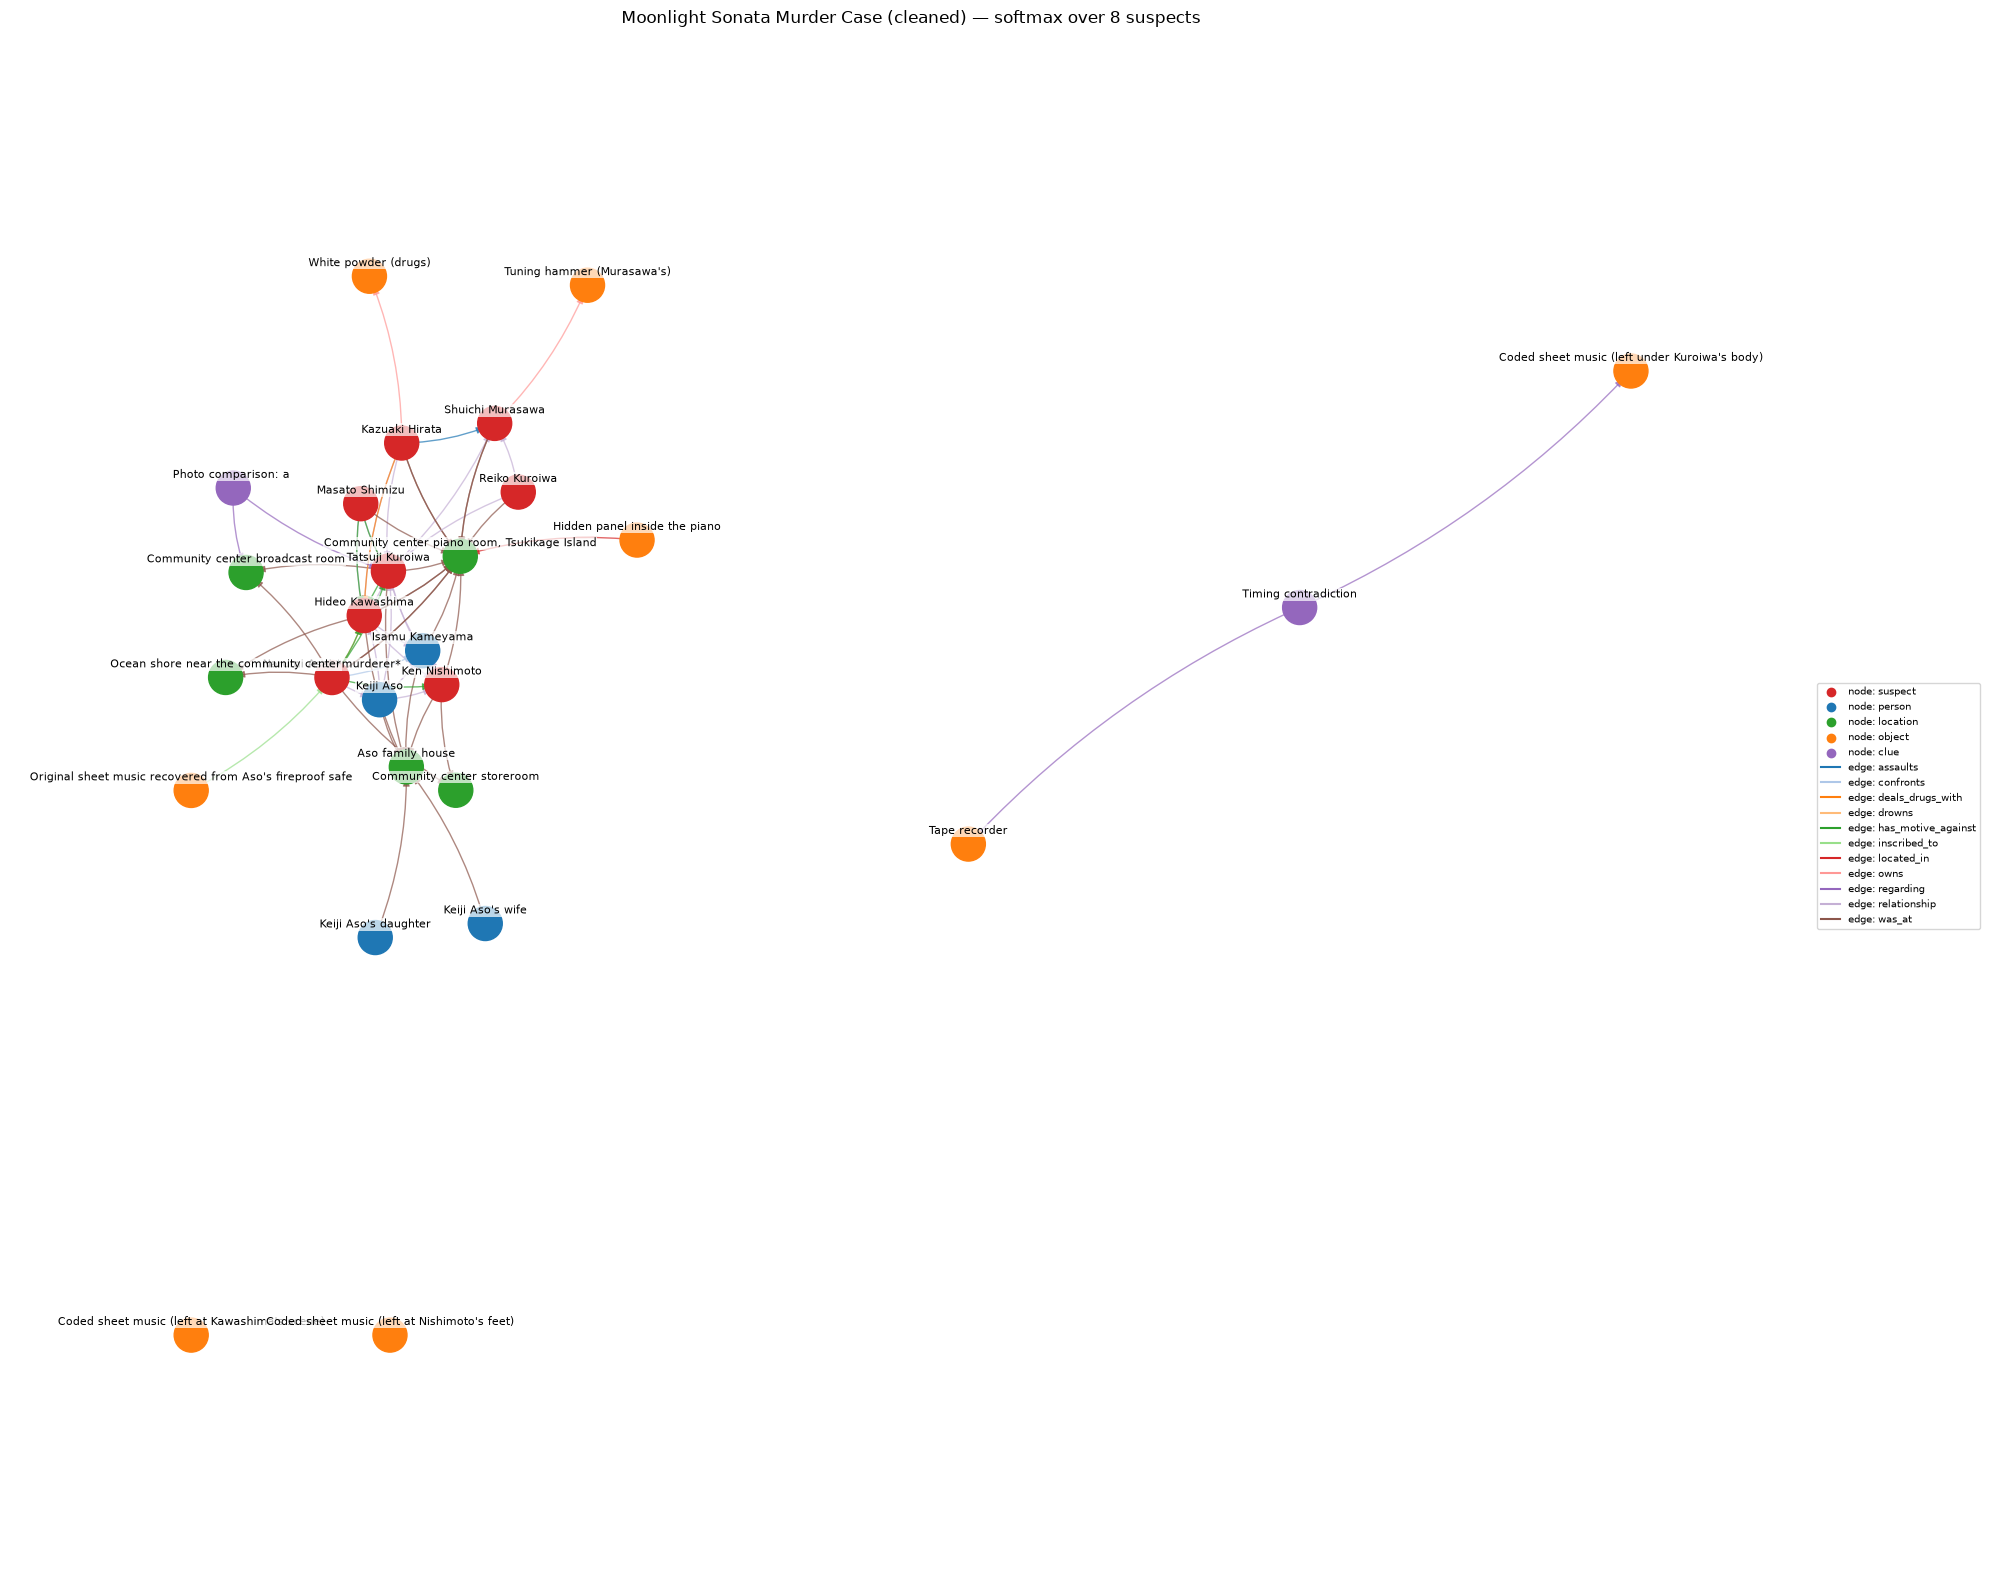

In [18]:
# --- visualize moonlight sonata (cleaned) -----------------------------------
example_clean = next(c for c in cleaned_cases if c["case_id"] == "ep011_moonlight_sonata_murder_case")

print(f"case: {example_clean['title']}")
print(f"edges before cleaning: {len(example['edges'])}   after: {len(example_clean['edges'])}")

draw_case(example_clean, title=f"{example_clean['title']} (cleaned) — softmax over {len(ex_suspects)} suspects")


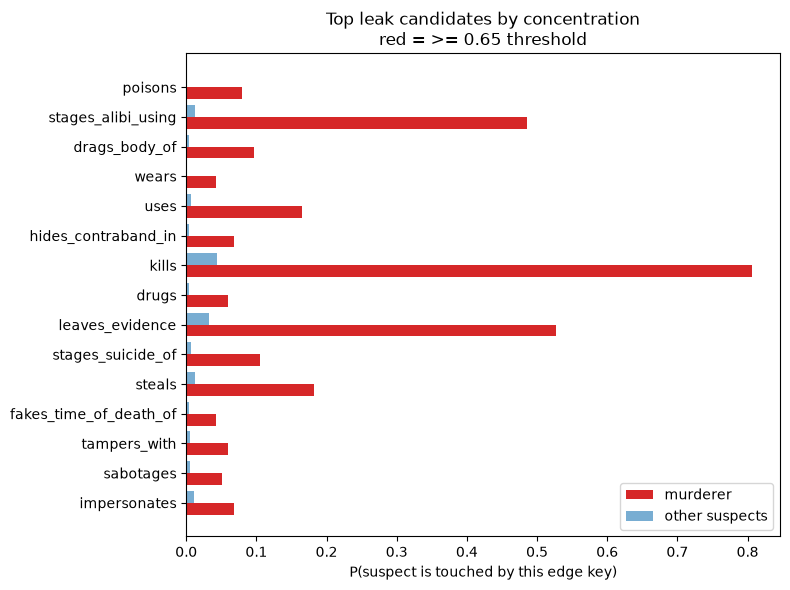

In [19]:
# --- viz: murderer-rate vs other-suspect-rate for the top leak candidates --
top = leak_df.head(15).iloc[::-1]
top_over = (top["category"] == "action") & (top["concentration"] >= EXCLUDE_THRESHOLD)
colors = ["tab:red" if over else "tab:gray" for over in top_over]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(top))
ax.barh(y - 0.2, top["murderer_rate"], height=0.4, color=colors, label="murderer")
ax.barh(y + 0.2, top["other_suspect_rate"], height=0.4, color="tab:blue", alpha=0.6, label="other suspects")
ax.set_yticks(y); ax.set_yticklabels(top["edge_key"])
ax.set_xlabel("P(suspect is touched by this edge key)")
ax.set_title(f"Top leak candidates by concentration\nred = >= {EXCLUDE_THRESHOLD} threshold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


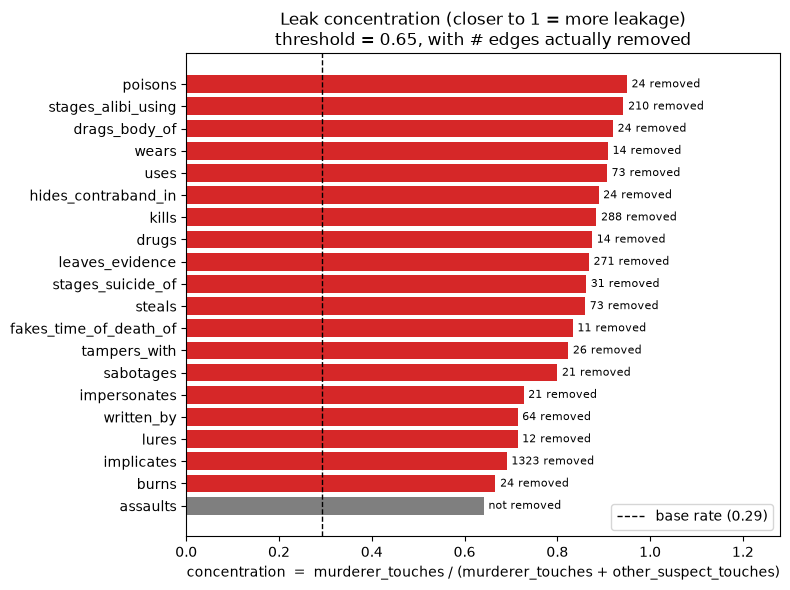

In [20]:
# --- viz: concentration score (0-1) + how many edges were actually removed -
top_conc = leak_df.head(20).iloc[::-1].copy()
top_conc["removed"] = top_conc["edge_key"].map(removed_edge_counts).fillna(0).astype(int)
top_over = (top_conc["category"] == "action") & (top_conc["concentration"] >= EXCLUDE_THRESHOLD)
colors = ["tab:red" if over else "tab:gray" for over in top_over]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(top_conc))
bars = ax.barh(y, top_conc["concentration"], color=colors)
ax.axvline(base_rate, color="black", linestyle="--", linewidth=1, label=f"base rate ({base_rate:.2f})")

# label each bar with how many edges of that type were removed corpus-wide
for bar, removed, over in zip(bars, top_conc["removed"], top_over):
    label = f"{removed} removed" if over else "not removed"
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, label,
            va="center", fontsize=8)

ax.set_yticks(y); ax.set_yticklabels(top_conc["edge_key"])
ax.set_xlim(0, 1.28)
ax.set_xlabel("concentration  =  murderer_touches / (murderer_touches + other_suspect_touches)")
ax.set_title(f"Leak concentration (closer to 1 = more leakage)\nthreshold = {EXCLUDE_THRESHOLD}, with # edges actually removed")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [21]:
# --- persist the leak table (now including removed-edge counts) ------------
leak_df["edges_removed"] = leak_df["edge_key"].map(removed_edge_counts).fillna(0).astype(int)

out_path = "leak_candidates_v5.csv"
leak_df.to_csv(out_path, index=False)
print(f"saved {len(leak_df)} rows to {out_path}")


saved 35 rows to leak_candidates_v5.csv


### Findings

- **Sanity check passed:** `was_at` scores concentration **0.300**,
  essentially identical to the corpus base rate (**0.292**) — the
  calibration check for the whole metric.
- **`poisons` (0.95), `stages_alibi_using` (0.94), `drags_body_of` (0.92)**
  are the strongest leaks. `kills` sits at **0.88** (216 touches, 191 the
  murderer). `implicates` scores lower (0.69) but has the highest raw
  volume of any key (343 touches, 237/237 cases) — still one of the most
  dangerous single edges in the corpus purely on reach.
- **19 edge types removed corpus-wide, 2,548 of 11,429 edges (22.3%).**
  `implicates` alone accounts for 1,323 of those removed edges — over half
  — followed by `kills` (288) and `leaves_evidence` (271). `ep011`
  (Moonlight Sonata) goes from 98 to 62 edges after cleaning, visible in
  the before/after renders above.
- `owns`, `assaults`, `confronts`, `blackmails`, `threatens`, and `frames`
  score between 0.48 and 0.64 — elevated but under the 0.65 line, so they
  were **kept**. `has_motive_against` (0.43) and every `rel:*` relationship
  type (0.30–0.42) score even lower and were never candidates for removal —
  motive/relationship edges are signal a real detective is allowed to use.

**On the graph falling apart into pieces:** stripping `implicates`, `kills`,
`owns`-adjacent action edges, etc. leaves a few evidence nodes (e.g. some
"coded sheet music" objects in `ep011`) with no edges left at all — visible
in the cleaned render above as small clusters or single dots off to the
side, no longer connected to the main graph. That's expected and not a bug:
those objects only existed in the story because they were narrated as
pointing at the killer, so removing the narration-only edges naturally
disconnects them, and message passing simply won't reach them for that
case — the same way a real detective doesn't get to link every piece of
evidence they collect. It's a genuine limitation worth naming explicitly in
the report, not something to quietly patch by deleting the now-isolated
nodes here: a future iteration could try giving every object/clue a
non-leaky fallback edge (e.g. to the location it was found in), but that's
a modeling decision for later, not a data-cleaning step.

**Still open (next steps, not covered in this notebook):** the
`relation_type`/action-verb bucket taxonomy started below, and the
case-level, suspect-count-stratified train/val/test split. The exported
`cases_v4` dataset is what GNN v2 (the "clean data" iteration in the wider
plan) should train against, compared back to a v1 model trained on the
original `cases_v3`.


## 3. Starting the bucket taxonomy (Section 7b)

Item 7 of the plan has two parts: (a) the exclusion list above, and (b)
collapsing the ~270 `relation_type` values (and, it turns out, the
long-tail `action` verbs too — 606 of them remain after cleaning) down to a
handful of buckets, because 606+270 distinct edge keys is not something a
relation-aware conv layer (RGCN/HGT/HeteroConv) can usefully learn a
separate embedding for, when most of them appear only a handful of times.

**What are "categories" here?** Every edge key falls into exactly one of
two categories, decided purely by whether it came from a `relationship`
edge or not:

- **`action`** — the edge's raw `type` string (`was_at`, `owns`, `kills`,
  ...). Describes something that *happened* (an event, a state, a piece of
  evidence).
- **`relationship`** — a `relationship`-type edge's `relation_type`,
  prefixed `rel:` (`rel:classmate`, `rel:spouse_of`, ...). Describes a
  *pre-existing social fact*, independent of the crime.

Every single edge has one or the other — there's no third case — because
the category is just "does this edge's collapsed key start with `rel:`",
which is true for every `relationship` edge and false for everything else
by construction (`_edge_relation_key` guarantees this). The cell below
counts every edge in the **cleaned** corpus (`cases_v4` — the dataset
future work should actually bin against) and checks that split adds up to
the total, then lists every distinct key with its category and frequency
as the starting catalog for actually assigning buckets (not done here —
that's the next step).


In [22]:
# --- full edge-key catalog of the cleaned corpus, ready for binning --------
edge_key_counter = Counter()
edge_key_category = {}
for c in cleaned_cases:
    for e in c["edges"]:
        key = _edge_relation_key(e)
        edge_key_counter[key] += 1
        edge_key_category[key] = "relationship" if key.startswith("rel:") else "action"

action_keys = sorted((k for k in edge_key_counter if edge_key_category[k] == "action"),
                      key=lambda k: -edge_key_counter[k])
relationship_keys = sorted((k for k in edge_key_counter if edge_key_category[k] == "relationship"),
                            key=lambda k: -edge_key_counter[k])

action_total = sum(edge_key_counter[k] for k in action_keys)
relationship_total = sum(edge_key_counter[k] for k in relationship_keys)
total_edges_cleaned = sum(len(c["edges"]) for c in cleaned_cases)
assert action_total + relationship_total == total_edges_cleaned  # every edge has exactly one category

print(f"{len(edge_key_counter)} distinct edge keys in cases_v4 "
      f"({len(action_keys)} action + {len(relationship_keys)} relationship)")
print(f"{action_total} action edges + {relationship_total} relationship edges "
      f"= {action_total + relationship_total} total edges -- every edge is categorized, confirmed")

print(f"\n=== action ({len(action_keys)} keys) ===")
for k in action_keys:
    print(f"  {k:28s} {edge_key_counter[k]:5d}")

print(f"\n=== relationship ({len(relationship_keys)} keys) ===")
for k in relationship_keys:
    print(f"  {k:28s} {edge_key_counter[k]:5d}")


876 distinct edge keys in cases_v4 (605 action + 271 relationship)
7542 action edges + 1339 relationship edges = 8881 total edges -- every edge is categorized, confirmed

=== action (605 keys) ===
  was_at                        2990
  regarding                     1294
  owns                           676
  has_motive_against             599
  located_in                     464
  confronts                      116
  assaults                        61
  frames                          28
  blackmails                      27
  discovers                       21
  accuses                         20
  threatens                       19
  hides                           16
  attempts_to_kill                15
  deceives                        14
  rigs                            14
  discovers_body_of               14
  gives                           14
  disposes_of                     13
  calls                           12
  plants                          12
  inscribed_to            